# Predicción de Abandono de Clientes (Churn) en Telecomunicaciones

---

**Autor:** Borja Mora Méndez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/borja-mora)
**Categoría:** Machine Learning · Supervisado · Clasificación · Comparativa de modelos

---

### Objetivo

Construir un clasificador que identifique **qué clientes tienen mayor probabilidad de darse de baja (churn)**, comparando tres algoritmos — Árbol de Decisión, Random Forest y XGBoost — para decidir de forma justificada cuál (si alguno) merece pasar a producción.

### Por qué comparar tres modelos y no lanzarse directamente al más complejo

| Modelo | Por qué se incluye en la comparativa |
|---|---|
| **Árbol de Decisión** | Máxima interpretabilidad — si funciona, produce reglas que el equipo de retención puede aplicar sin depender de un data scientist |
| **Random Forest** | Referencia de robustez — promedia 100 árboles, reduce varianza frente a un único árbol |
| **XGBoost** | Referencia de rendimiento máximo — el estándar de boosting; si ni XGBoost encuentra señal, el problema no es el algoritmo |

> **Adelanto del hallazgo:** en este caso, los tres modelos convergen en la misma conclusión — no logran distinguir señal de ruido con las variables disponibles. Diagnosticar **por qué** ocurre esto, y qué hacer al respecto, es tan valioso para el negocio como si hubiéramos encontrado el modelo perfecto. Un analista junior entregaría el modelo con mejor accuracy sin más preguntas; este notebook explica por qué esa accuracy es una ilusión estadística.

## 1. Contexto de negocio

**El cliente:** operador de telecomunicaciones con una base de clientes residenciales.

**El problema:** antes de cada renovación anual, el equipo de retención contacta **a toda la cartera de clientes por igual** con ofertas de permanencia. Es una campaña cara y poco eficiente: solo alrededor del **9% de los clientes** acaba dándose de baja, así que el 91% de las llamadas y descuentos se destinan a clientes que de todos modos iban a quedarse.

**El impacto económico:** si se pudiera anticipar qué clientes están en riesgo real de abandonar, el presupuesto de retención podría concentrarse en ese ~9%, multiplicando la eficiencia de cada campaña y liberando recursos comerciales para captación.

**La pregunta analítica:** con los datos que ya tiene la compañía en su CRM — edad, ingresos, antigüedad y gasto mensual — **¿es posible predecir qué clientes van a darse de baja?**

## 2. Stack técnico

| Librería | Uso |
|---|---|
| `pandas` | Manipulación y exploración de datos |
| `matplotlib`, `seaborn` | Visualización |
| `scikit-learn` | Modelos de clasificación (Árbol, Random Forest), partición train/test y métricas |
| `xgboost` | Modelo de boosting para la comparativa |

In [1]:
# === Manipulación de datos ===
import pandas as pd
import numpy as np

# === Visualización ===
import matplotlib.pyplot as plt
import seaborn as sns

# === Modelado ===
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)
from xgboost import XGBClassifier

# === Configuración visual ===
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

## 3. Carga y exploración inicial de los datos

### Variables del dataset

| Variable | Tipo | Descripción |
|---|---|---|
| `idcliente` | int | Identificador único del cliente (no se usa como predictor) |
| `Edad` | Numérica | Edad del cliente en años |
| `Ingresos` | Numérica | Ingresos mensuales estimados del cliente |
| `Antiguedad` | Numérica | Años como cliente de la compañía |
| `GastoMensual` | Numérica | Gasto mensual medio en el servicio |
| `Churn` | Binaria (target) | 1 = el cliente se ha dado de baja, 0 = permanece |

In [2]:
data = pd.read_excel("customer churn.xlsx")

print(f"Registros: {data.shape[0]} | Columnas: {data.shape[1]}")
data.head()

Registros: 1234 | Columnas: 6


,idcliente,Edad,Ingresos,Antiguedad,GastoMensual,Churn
0,1,33,2845.202995,11,36.168961,0
1,2,66,6063.797330,7,27.149305,0
2,3,56,2593.151291,13,46.387221,0
3,4,55,7075.617838,18,12.359331,0
4,5,65,6690.148651,21,35.445138,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1234 entries, 0 to 1233
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   idcliente     1234 non-null   int64  
 1   Edad          1234 non-null   int64  
 2   Ingresos      1234 non-null   float64
 3   Antiguedad    1234 non-null   int64  
 4   GastoMensual  1234 non-null   float64
 5   Churn         1234 non-null   int64  
dtypes: float64(2), int64(4)
memory usage: 58.0 KB


In [4]:
data.describe().round(2)

,idcliente,Edad,Ingresos,Antiguedad,GastoMensual,Churn
count,1234.00,1234.00,1234.00,1234.00,1234.00,1234.00
mean,617.50,43.47,4045.73,12.58,21.39,0.09
std,356.37,15.15,2787.44,7.49,14.41,0.29
min,1.00,18.00,1000.00,0.00,-4.28,0.00
25%,309.25,30.00,1563.94,6.00,8.77,0.00
50%,617.50,43.00,3185.51,13.00,21.13,0.00
75%,925.75,57.00,6240.40,19.00,33.43,0.00
max,1234.00,70.00,9998.79,25.00,46.74,1.00


In [5]:
churn_rate = data["Churn"].value_counts(normalize=True)
print("Distribución de la variable objetivo (Churn):")
print(f"  No Churn (0): {churn_rate[0]:.1%}")
print(f"  Churn (1):    {churn_rate[1]:.1%}")

Distribución de la variable objetivo (Churn):
  No Churn (0): 90.7%
  Churn (1):    9.3%


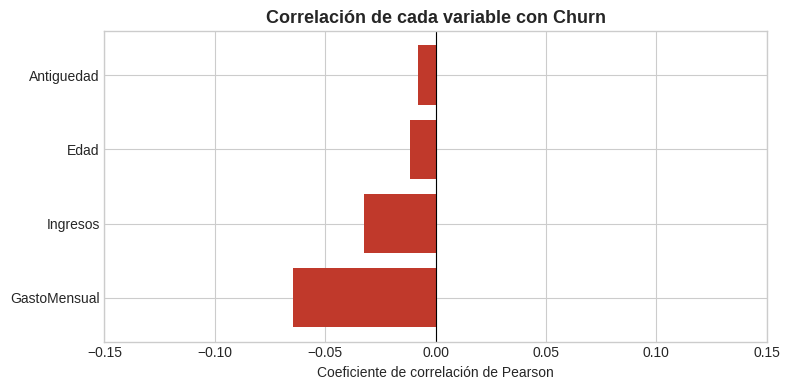

Correlaciones exactas:
GastoMensual   -0.0644
Ingresos       -0.0325
Edad           -0.0116
Antiguedad     -0.0078
Name: Churn, dtype: float64


In [6]:
# ¿Hay señal? Correlación de cada variable con el churn
correlaciones = data.drop(columns=["idcliente"]).corr(numeric_only=True)["Churn"].drop("Churn").sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#c0392b" if v < 0 else "#2980b9" for v in correlaciones.values]
ax.barh(correlaciones.index, correlaciones.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlación de cada variable con Churn", fontsize=13, fontweight="bold")
ax.set_xlabel("Coeficiente de correlación de Pearson")
ax.set_xlim(-0.15, 0.15)
plt.tight_layout()
plt.show()

print("Correlaciones exactas:")
print(correlaciones.round(4))

### Lectura rápida de la exploración

Dos señales de alerta antes de entrenar ningún modelo:

1. **Desequilibrio de clases:** solo el 9,3% de los clientes se ha dado de baja. Esto significa que un modelo "tonto" que prediga **siempre "No Churn"** ya acertaría en el 90,7% de los casos. Cualquier modelo que evaluemos tiene que superar claramente ese suelo — no basta con mirar el accuracy.
2. **Correlación casi nula:** ninguna de las 4 variables disponibles supera |r| = 0,07 de correlación con el churn. Para contexto, se suele considerar que una correlación empieza a ser relevante a partir de |r| ≈ 0,3. Esto es una pista temprana de que **estas variables por sí solas pueden no contener la señal que buscamos** — lo confirmaremos (o refutaremos) con los modelos.

## 4. Preparación de datos para el modelo

Seleccionamos las 4 variables predictoras disponibles y separamos el target. Usamos `stratify=y` en la partición train/test para preservar la proporción real de churners (9,3%) en ambos conjuntos — imprescindible en un problema desequilibrado como este.

In [7]:
X = data[["Edad", "Ingresos", "Antiguedad", "GastoMensual"]]
y = data["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} registros ({y_train.mean():.1%} churn) | "
      f"Test: {X_test.shape[0]} registros ({y_test.mean():.1%} churn)")

Train: 987 registros (9.3% churn) | Test: 247 registros (9.3% churn)


La estratificación funciona correctamente: ambos conjuntos mantienen ~9,3% de churn. El punto de referencia (baseline) que cualquier modelo debe batir en el conjunto de test es **90,7% de accuracy** — la que se obtendría prediciendo "No Churn" para todo el mundo, sin usar ningún dato.

## 5. Modelo 1 · Árbol de Decisión

Empezamos con el modelo más interpretable: si el árbol encuentra reglas claras, el equipo de retención podría aplicarlas sin depender de un modelo en producción.

### 5.1 Entrenamiento

In [8]:
tree = DecisionTreeClassifier(max_depth=6, random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)
y_proba_tree = tree.predict_proba(X_test)[:, 1]

### 5.2 Evaluación

In [9]:
acc_tree = accuracy_score(y_test, y_pred_tree)
rec_tree = recall_score(y_test, y_pred_tree)
auc_tree = roc_auc_score(y_test, y_proba_tree)

print("Árbol de Decisión — Métricas de evaluación")
print(f"Accuracy: {acc_tree:.1%}")
print(f"Recall (churners detectados): {rec_tree:.1%}")
print(f"AUC-ROC: {auc_tree:.3f}")
print()
print(classification_report(y_test, y_pred_tree, target_names=["No Churn", "Churn"]))

Árbol de Decisión — Métricas de evaluación
Accuracy: 90.3%
Recall (churners detectados): 4.3%
AUC-ROC: 0.575

              precision    recall  f1-score   support

    No Churn       0.91      0.99      0.95       224
       Churn       0.33      0.04      0.08        23

    accuracy                           0.90       247
   macro avg       0.62      0.52      0.51       247
weighted avg       0.86      0.90      0.87       247



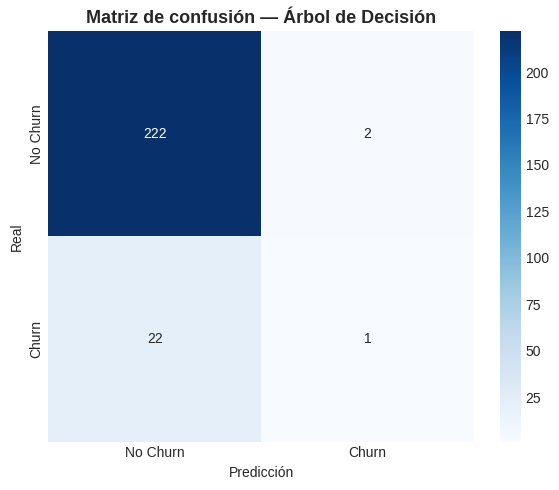

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
cm_tree = confusion_matrix(y_test, y_pred_tree)
sns.heatmap(cm_tree, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"], ax=ax)
ax.set_title("Matriz de confusión — Árbol de Decisión", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

**Interpretación — la trampa del accuracy:**

El árbol logra un accuracy del **90,3%**, un número que a primera vista parece excelente. Pero la matriz de confusión revela la realidad: de los **23 clientes que realmente se dieron de baja** en el conjunto de test, el modelo solo detectó **1**. El recall de la clase Churn es del **4,3%** — el modelo es, a efectos prácticos, casi tan ciego al churn real como el baseline que predice "No Churn" para todos.

El **AUC-ROC de 0,575** confirma el diagnóstico: un modelo sin ninguna capacidad predictiva tendría AUC = 0,500 (equivalente a lanzar una moneda). Un 0,575 está apenas por encima del azar — no es una señal en la que el negocio pueda apoyarse para decidir a quién llamar.

### 5.3 Visualización del árbol

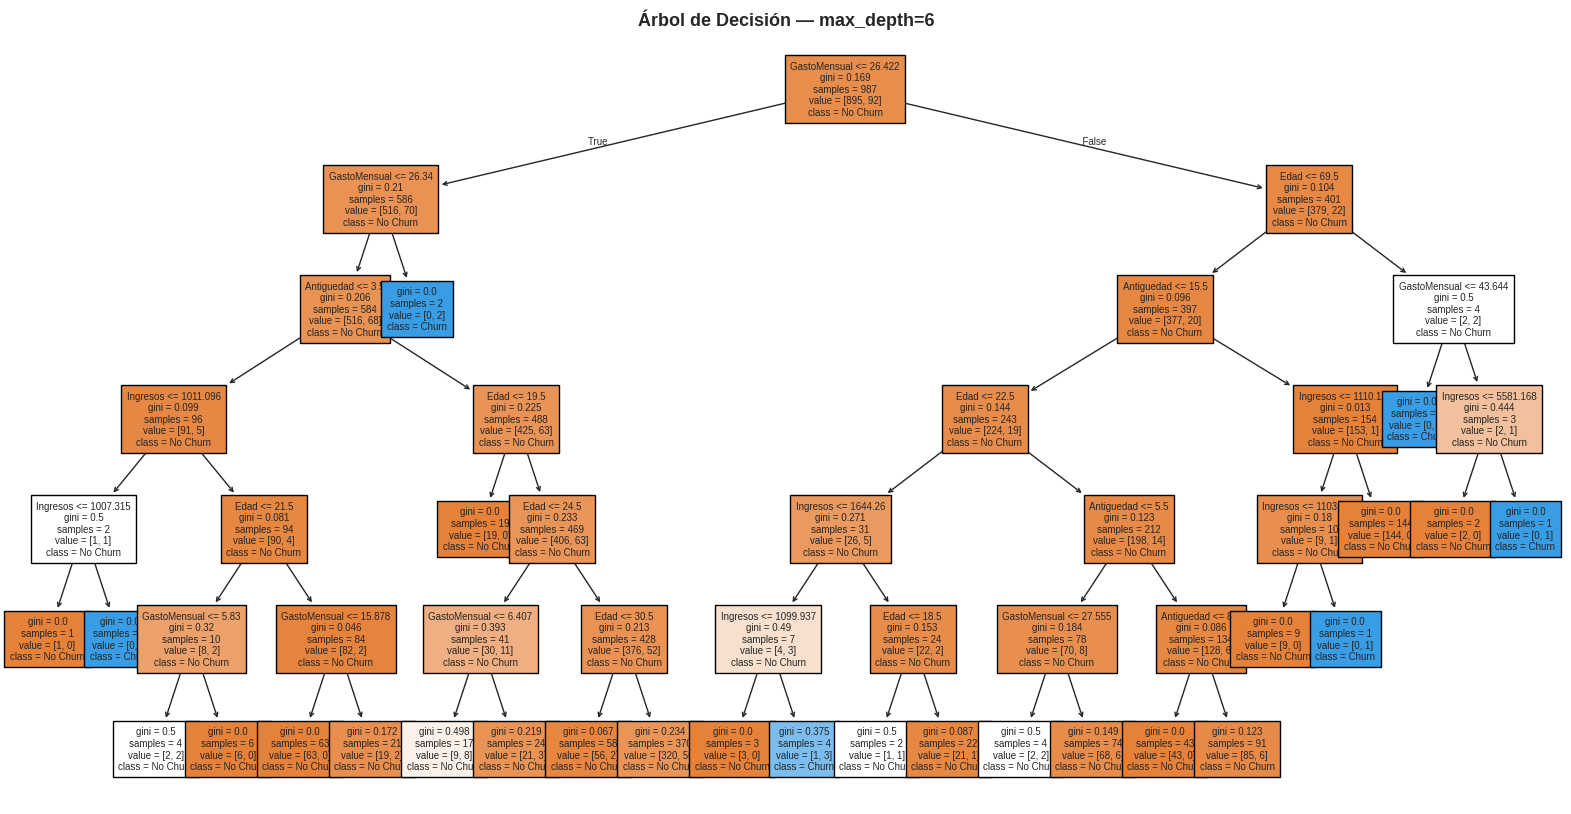

In [11]:
plt.figure(figsize=(20, 10))
plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["No Churn", "Churn"],
    filled=True,
    fontsize=7,
)
plt.title("Árbol de Decisión — max_depth=6", fontsize=13, fontweight="bold")
plt.show()

### 5.4 Interpretación de negocio — cuando las reglas no dicen nada

Al leer las reglas del árbol (ampliadas en la sección 5.6) aparece un patrón revelador de **sobreajuste al ruido**: el primer nodo divide a los clientes por `Ingresos ≤ 1.007,32 €` frente a `Ingresos > 1.007,32 €` — un umbral tan específico y arbitrario que no corresponde a ningún criterio de negocio real (una tarifa, un tramo de renta, un producto contratado). Es la firma típica de un árbol que ha aprendido a memorizar particularidades del conjunto de entrenamiento en lugar de una relación causal real con el churn.

**Lectura operativa:** si estas reglas se llevaran tal cual a un director de operaciones, no podría actuar sobre ellas — no existe un umbral de ingresos de "1.007 €" que tenga sentido comercial. Esto es la confirmación práctica de lo que ya apuntaba la correlación casi nula de la sección 3.

### 5.5 Importancia de las variables

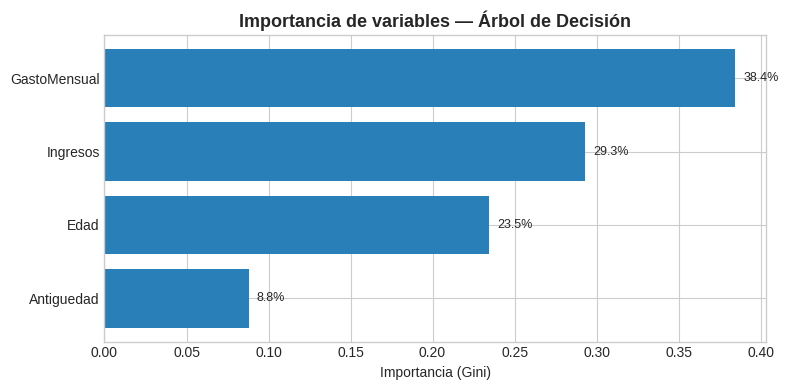

,feature,importance
3,GastoMensual,0.384344
1,Ingresos,0.293182
0,Edad,0.234669
2,Antiguedad,0.087805


In [12]:
importancias_tree = pd.DataFrame({
    "feature": X.columns,
    "importance": tree.feature_importances_
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(importancias_tree["feature"], importancias_tree["importance"], color="#2980b9")
for i, v in enumerate(importancias_tree["importance"]):
    ax.text(v + 0.005, i, f"{v:.1%}", va="center", fontsize=9)
ax.invert_yaxis()
ax.set_title("Importancia de variables — Árbol de Decisión", fontsize=13, fontweight="bold")
ax.set_xlabel("Importancia (Gini)")
plt.tight_layout()
plt.show()

importancias_tree

`GastoMensual` concentra la mayor importancia (38,4%), seguida de `Ingresos` (29,3%) y `Edad` (23,5%). A diferencia del caso del gimnasio, aquí ninguna variable domina de forma aplastante (98,9% en aquel caso) — la importancia está repartida porque **el árbol está buscando patrones donde apenas los hay**, no porque exista una variable predictora fuerte.

### 5.6 Reglas del árbol en formato texto

In [13]:
reglas = export_text(tree, feature_names=list(X.columns))
print(reglas)

|--- GastoMensual <= 26.42
|   |--- GastoMensual <= 26.34
|   |   |--- Antiguedad <= 3.50
|   |   |   |--- Ingresos <= 1011.10
|   |   |   |   |--- Ingresos <= 1007.32
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Ingresos >  1007.32
|   |   |   |   |   |--- class: 1
|   |   |   |--- Ingresos >  1011.10
|   |   |   |   |--- Edad <= 21.50
|   |   |   |   |   |--- GastoMensual <= 5.83
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- GastoMensual >  5.83
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- Edad >  21.50
|   |   |   |   |   |--- GastoMensual <= 15.88
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- GastoMensual >  15.88
|   |   |   |   |   |   |--- class: 0
|   |   |--- Antiguedad >  3.50
|   |   |   |--- Edad <= 19.50
|   |   |   |   |--- class: 0
|   |   |   |--- Edad >  19.50
|   |   |   |   |--- Edad <= 24.50
|   |   |   |   |   |--- GastoMensual <= 6.41
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- GastoMensu

## 6. Modelo 2 · Random Forest

Un árbol único puede sobreajustar a particularidades del conjunto de entrenamiento — justo lo que hemos observado. Un Random Forest entrena **100 árboles** sobre submuestras aleatorias y promedia sus predicciones, lo que debería suavizar ese ruido si es que existe alguna señal real por debajo.

In [14]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

print("Random Forest — Métricas de evaluación")
print(f"Accuracy: {acc_rf:.1%}")
print(f"Recall (churners detectados): {rec_rf:.1%}")
print(f"AUC-ROC: {auc_rf:.3f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=["No Churn", "Churn"]))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest — Métricas de evaluación
Accuracy: 90.7%
Recall (churners detectados): 0.0%
AUC-ROC: 0.524

              precision    recall  f1-score   support

    No Churn       0.91      1.00      0.95       224
       Churn       0.00      0.00      0.00        23

    accuracy                           0.91       247
   macro avg       0.45      0.50      0.48       247
weighted avg       0.82      0.91      0.86       247

Matriz de confusión:
[[224   0]
 [ 23   0]]


/sessions/zen-stoic-carson/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/sessions/zen-stoic-carson/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/sessions/zen-stoic-carson/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

**Lectura:** el Random Forest sube el accuracy a **90,7%** — pero solo porque predice "No Churn" para **el 100% de los clientes del test**. Su recall sobre la clase Churn es **0%**: no detecta ni un solo cliente en riesgo real. Promediar 100 árboles no ha creado señal donde no la había; simplemente ha eliminado el ruido que hacía que el árbol único acertara 1 caso por azar. El AUC de **0,524** lo confirma — prácticamente indistinguible de 0,500.

## 7. Modelo 3 · XGBoost

XGBoost es el estándar de facto en competiciones de Machine Learning con datos tabulares. Lo incluimos por completitud: si ni siquiera el algoritmo de boosting más potente encuentra señal, el problema no es la elección de algoritmo — es la falta de variables predictivas relevantes en los datos.

In [15]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

acc_xgb = accuracy_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)

print("XGBoost — Métricas de evaluación")
print(f"Accuracy: {acc_xgb:.1%}")
print(f"Recall (churners detectados): {rec_xgb:.1%}")
print(f"AUC-ROC: {auc_xgb:.3f}")
print()
print(classification_report(y_test, y_pred_xgb, target_names=["No Churn", "Churn"]))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost — Métricas de evaluación
Accuracy: 89.5%
Recall (churners detectados): 0.0%
AUC-ROC: 0.499

              precision    recall  f1-score   support

    No Churn       0.91      0.99      0.94       224
       Churn       0.00      0.00      0.00        23

    accuracy                           0.89       247
   macro avg       0.45      0.49      0.47       247
weighted avg       0.82      0.89      0.86       247

Matriz de confusión:
[[221   3]
 [ 23   0]]


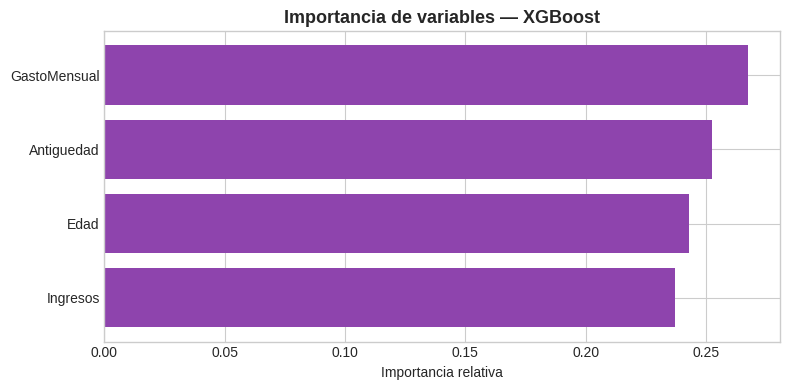

In [16]:
importancias_xgb = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(importancias_xgb.index, importancias_xgb.values, color="#8e44ad")
ax.invert_yaxis()
ax.set_title("Importancia de variables — XGBoost", fontsize=13, fontweight="bold")
ax.set_xlabel("Importancia relativa")
plt.tight_layout()
plt.show()

**Lectura:** XGBoost obtiene un accuracy del **89,5%** — por debajo incluso del baseline ingenuo — y un **AUC de 0,499**, literalmente indistinguible de una predicción aleatoria. Además, las cuatro variables reciben una importancia casi idéntica (24-27% cada una), lo cual es otra huella característica de ausencia de señal: cuando existe una variable realmente predictiva, el modelo se apoya en ella de forma desproporcionada (como vimos en el caso del gimnasio, donde una sola variable explicaba el 98,9%). Aquí, al no encontrar ninguna relación fuerte, el modelo reparte la importancia casi por igual entre todas.

Los tres modelos convergen en la misma conclusión por rutas distintas: **no hay señal aprovechable en estas cuatro variables.**

## 8. Comparativa de los tres modelos

| Modelo | Accuracy | Recall (churn) | AUC-ROC | Interpretabilidad | Recomendación |
|---|:---:|:---:|:---:|:---:|---|
| **Baseline** (predecir siempre "No Churn") | 90,7% | 0,0% | 0,500 | — | Referencia de suelo |
| **Árbol de Decisión** | 90,3% | 4,3% | 0,575 | Alta | Descartado — recall insuficiente, reglas no accionables |
| **Random Forest** | 90,7% | 0,0% | 0,524 | Media | Descartado — no detecta ningún churner |
| **XGBoost** | 89,5% | 0,0% | 0,499 | Baja | Descartado — rendimiento igual al azar |

**Conclusión:** ninguno de los tres modelos supera de forma significativa al azar (AUC entre 0,50 y 0,58, cuando 0,70+ sería el mínimo exigible para un modelo operativo de churn). El Árbol de Decisión es "el menos malo" y el más transparente sobre sus propias limitaciones, pero **ningún modelo de esta comparativa está listo para producción**. Recomendar el que tiene mayor accuracy (Random Forest, 90,7%) sin mirar el recall sería el error clásico de quien no ha comprobado el desequilibrio de clases — exactamente el error que este análisis evita.

## 9. Insights de negocio y recomendaciones

### El hallazgo

> Las cuatro variables disponibles en el CRM — **Edad, Ingresos, Antigüedad y Gasto mensual** — no contienen señal predictiva sobre el churn. Su correlación individual con la baja es prácticamente nula (todas por debajo de |r| = 0,07) y los tres algoritmos probados, incluido el estándar de boosting XGBoost, obtienen un AUC-ROC de entre 0,50 y 0,58 — el rango del puro azar.

Esto **no es un fallo del análisis**: es el resultado correcto de la pregunta que se le hizo a los datos. El problema no es "qué algoritmo usar", sino "qué variables nos faltan".

